<img src=logo.png width=200px>

# soilice - coupled snow-soil model runs

To do:

- Make a pip package for local installation.
- Experiment with this in a clean virtual environment. IMPORTANT - don't install on main environment.
- When it works people will clone my github then pip install and then they can import the model. Alana will do this, so she will not have local copies of src_soil etc.
- ChatGPT can help me do all of this.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import pickle

from soilice.src_coupled import run
from soilice.src_soil import MakeDictFloat
from soilice.src_soil import MakeDictArray
from soilice.balanceChecks import snowBalanceCheck
from soilice.balanceChecks import soilBalanceCheck

In [2]:
# Import soil parameters:
from soilice.HP_loam import pars
# Import thermal parameters:
from soilice.snowParameters import pars as snowPars
for key in snowPars: pars[key]=snowPars[key]
from soilice.thermalSoilParameters import pars as thermalPars
for key in thermalPars: pars[key]=thermalPars[key]
    
# Soil model options:
opts={}
opts['massflag']=1.              # Solve correct equations (set to zero to remove Cdtheta/dt)
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=0.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=1.         # 0. no conduction on lower BC; 1. conduction based on TBot
opts['simulateFlow']=True        # 0. no flow, constant total water content; 1. simulates flow
opts['simulateTransport']=True   # 0. no flow, constant total water content; 1. simulates heat transport
opts['freeDrainage']=1.          # 0. no flow lower BC, 1.0 free draining lowerBC
opts['groundHeatFlux']=1.        # 0. no specified ground heat flux; 1. use specified ground heat flux.

# Import constants:
from soilice.constants import const

In [3]:
parsD=MakeDictFloat()
for k in pars: parsD[k]=pars[k]

In [4]:
# Load driving data:
start='1-Oct-2015'
# end='10-Oct-2015'
end='30-Sep-2019'
# end='30-Sep-2016'

dd=pd.read_pickle('drivingdata.pkl').loc[start:end]

In [5]:
# Soil space grid
dz=0.1
zMax=3.0
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

In [6]:
# Initial conditions:
# Soil:
T0=np.zeros(nz)+2.
psi0=np.zeros(nz)-1.
# Snow:
msini=0.
Tsini=0.

In [7]:
# Lower boundary condition
nt=len(dd)
TBot=np.zeros(nt)+1.

In [8]:
t,snow_df,qST,jST,qSB,jSB,psie,T,thetaL,thetaI=run(dd,dz,nz,parsD,const,opts,T0,psi0,msini,Tsini,TBot)

/Users/ani378/Desktop/soilice_package/.venv/lib/python3.12/site-packages/scipy/integrate/_ode.py:438: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


ode, with jac runtime = 39.64 seconds


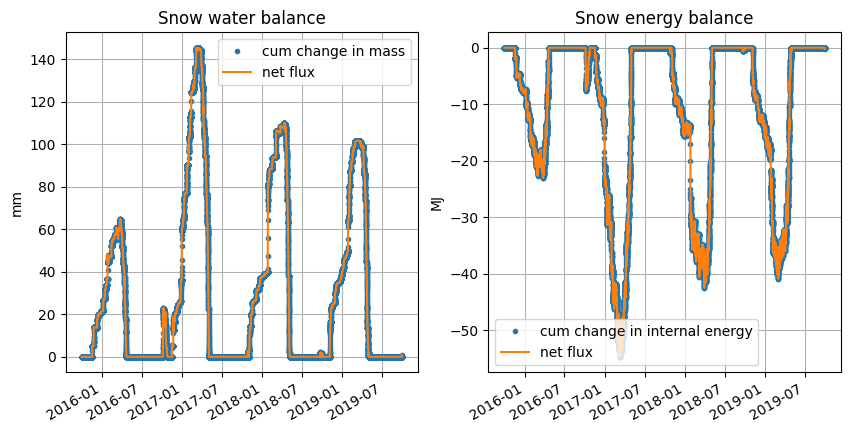

In [9]:
snowBalanceCheck(snow_df)

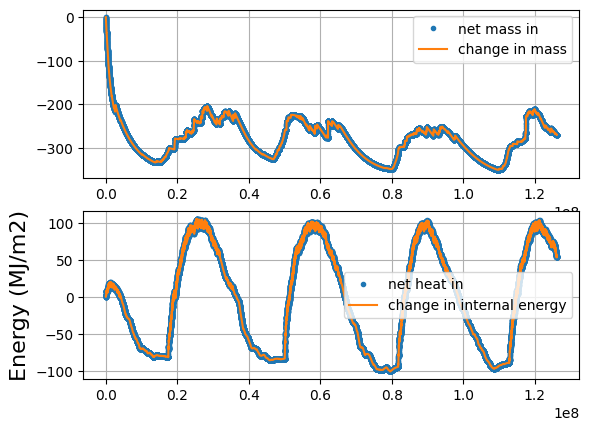

In [10]:
soilBalanceCheck(t,thetaL,thetaI,T,qST,qSB,jST,jSB,dz,const,pars)

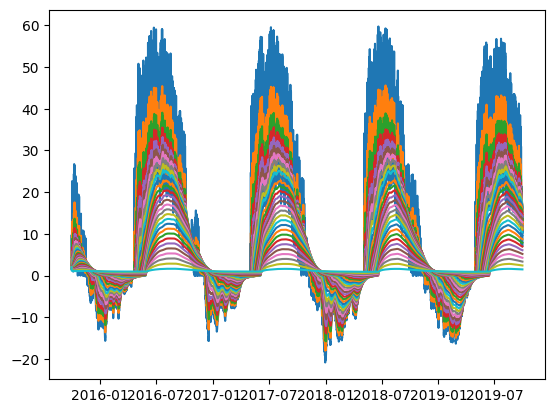

In [11]:
pl.plot(dd.index,T)
pl.show()

(3.0, 0.0)

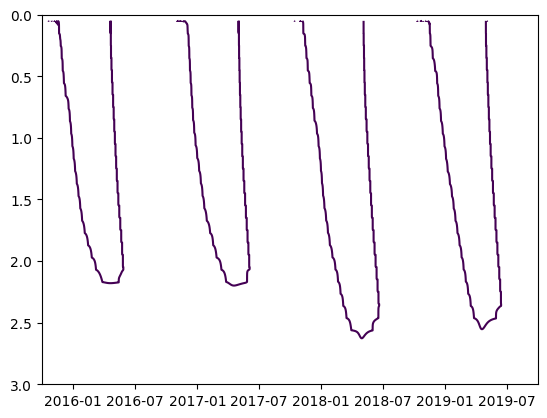

In [12]:
pl.contour(dd.index,z,T.T,[0])
pl.ylim(3,0)

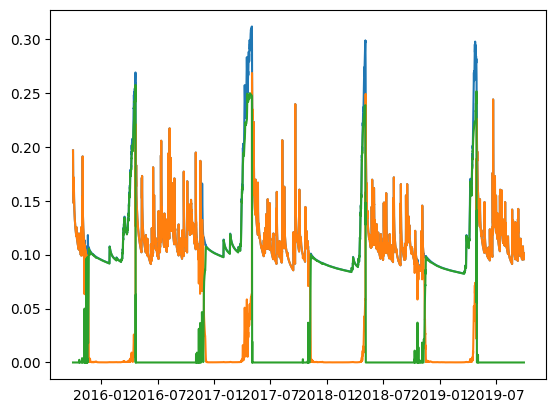

In [13]:
pl.plot(dd.index,thetaL[:,0]+thetaI[:,0])
pl.plot(dd.index,thetaL[:,0])
pl.plot(dd.index,thetaI[:,0])
pl.show()

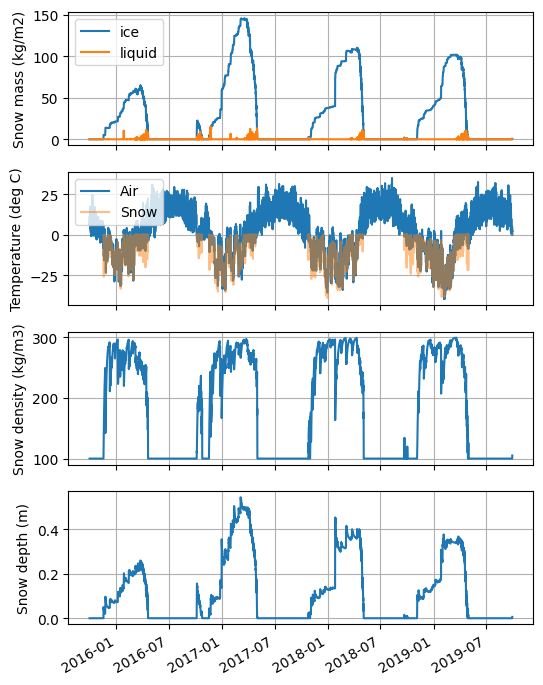

In [14]:
# Plots
d=dd.index
pl.figure(figsize=(6,9))
pl.subplot(4,1,1)
# pl.plot(tD,msD)
pl.plot(snow_df['mi'],label='ice')
pl.plot(snow_df['ml'],label='liquid')
# pl.plot(d,ml+mi,label='total')
# pl.plot(d,qD,label='Cum. snow drainage')
# pl.plot(d,P.cumsum(),label='Precipitation')
pl.ylabel('Snow mass (kg/m2)'); pl.grid()
pl.legend()

pl.subplot(4,1,2)
pl.plot(d,dd['T'],label='Air')
pl.plot(snow_df['Ts'],label='Snow',alpha=0.5)
pl.legend()
pl.ylabel('Temperature (deg C)'); pl.grid()

pl.subplot(4,1,3)
# pl.plot(d[1:],np.diff(jRn))
# pl.plot(d,u)
# pl.ylim(-50000,0000)
# # pl.plot(tD,rhoSD)
pl.plot(snow_df['rhoS'])
pl.ylabel('Snow density (kg/m3)'); pl.grid()

pl.subplot(4,1,4)
# pl.plot(tD,msD/rhoSD)
pl.plot(snow_df['mi']/snow_df['rhoS'])
pl.ylabel('Snow depth (m)'); pl.grid()

pl.gcf().autofmt_xdate()


In [15]:
output={}
for key in snow_df: output[key]=snow_df[key].values
output['dd']=dd
output['t']=t
output['pars']=pars
output['const']=const
output['psie']=psie
output['Tsoil']=T
output['thetaL']=thetaL
output['thetaI']=thetaI
output['qST']=qST
output['qSB']=qSB
output['jST']=jST
output['jSB']=jSB

In [16]:
for key in output: print(key)
output['Ts']

mi
ml
u
qR_snow
qS
qD
qE_snow
qM
qR_ground
jRn_snow
jG
jE_snow
jH_snow
jAPS
jAPR
jRn_ground
rhoS
d
Ta
Ts
dd
t
pars
const
psie
Tsoil
thetaL
thetaI
qST
qSB
jST
jSB


array([       nan,        nan,        nan, ..., 0.00114646, 0.00096117,
       0.00064342], shape=(35041,))

In [17]:
# import pickle
# def readOutput(filename):
#     with open(filename, 'rb') as f: output=pickle.load(f)
#     output['d']=output['dd'].index
#     return output

# coup=readOutput('coupledOut_noopts.pkl')
# coup['Tsoil'][0,:]

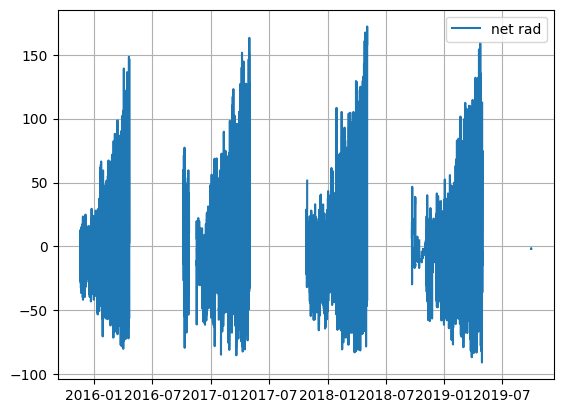

In [18]:
d=dd.index
# pl.plot(dd['SW']*0.2,label='net SW')
# pl.plot(dd['LW'],label='In LW')
LWout=pars['emissivitySnow']*const['stefanBoltzmann']*(output['Ts']+273.15)**4
# pl.plot(d[1:-1],LWout[1:-1],label='net LW')
pl.plot(d[1:-1],dd['SW'].iloc[1:-1]*0.2+dd['LW'].iloc[1:-1]-LWout[1:-1],label='net rad')
# # pl.plot(d,dd['LW']-LWout)
# pl.plot(d,(dd['LW']-LWout+dd['SW']*0.2).cumsum()*3600)
# pl.plot(d[1:],np.diff(jRn)/3600,label='jRn')

# pl.plot(d[1:-1],np.diff(jRn[:-1]/3600),label='jRn')
# pl.plot(d[1:-1],np.diff(jH[:-1]/3600),label='jH')
# pl.plot(d[1:-1],np.diff(jG[:-1]/3600),label='jG')
# pl.plot(d[1:-1],np.diff(jE[:-1]/3600),label='jE')
# pl.plot(d,jE,label='jE')

# pl.plot(d[1:-1],np.diff(u[:-1]/3600),'k',label='u')

# pl.plot(d,Ts,'-b',label='Ts')
pl.legend()

# pl.plot(d,jRn)
# pl.plot(d,jAPR)
# pl.plot(d,jRn-jH-jG)
# pl.plot(d,u-jAPS-jAPR)
# pl.plot(d[:1],np.diff(jRn))
# pl.ylim(-50,40)
# pl.xlim(pd.to_datetime('2015-11-18 00:00'),pd.to_datetime('2015-11-19 12:00'))
# pl.xlim(pd.to_datetime('2015-11-18 22:00'),pd.to_datetime('2015-11-19 12:00'))
pl.grid()

NameError: name 'Ts' is not defined

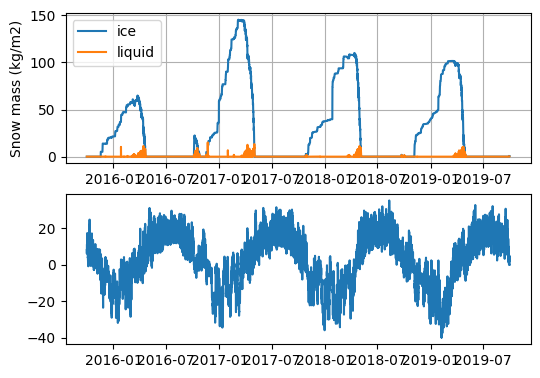

In [19]:
# Plots
d=dd.index
pl.figure(figsize=(6,9))
pl.subplot(4,1,1)
# pl.plot(tD,msD)
pl.plot(output['d'],output['mi'],label='ice')
pl.plot(output['d'],output['ml'],label='liquid')
# pl.plot(d,ml+mi,label='total')
# pl.plot(d,qD,label='Cum. snow drainage')
# pl.plot(d,P.cumsum(),label='Precipitation')
pl.ylabel('Snow mass (kg/m2)'); pl.grid()
pl.legend()

pl.subplot(4,1,2)
pl.plot(d,dd['T'],label='Air')
pl.plot(d,Ts,label='Snow',alpha=0.5)
pl.legend()
pl.ylabel('Temperature (deg C)'); pl.grid()
pl.subplot(4,1,3)
# pl.plot(tD,rhoSD)
pl.plot(d,rhoS)
pl.ylabel('Snow density (kg/m3)'); pl.grid()
pl.subplot(4,1,4)
# pl.plot(tD,msD/rhoSD)
pl.plot(d,mi/rhoS)
pl.ylabel('Snow depth (m)'); pl.grid()

pl.gcf().autofmt_xdate()

pl.savefig('temperature_balance_snow.png')

In [ ]:
# pl.plot(d,(mi+ml)-(mi+ml)[0],'.',label='cum change in mass')
pl.plot(dd['P'].cumsum()*3600,label='precip')
pl.plot(snow_df['qR_snow'].cumsum(),label='rain on snow')
pl.plot(snow_df['qS'].cumsum(),label='snowfall')
pl.plot(snow_df['qE_snow'].cumsum(),label='snow evap')
pl.plot(snow_df['qD'].cumsum(),label='snow drainage')
pl.plot(snow_df['qR_ground'].cumsum(),label='rain on ground')
# +qS-qE-qD,label='net flux')
pl.legend()
pl.grid()

In [ ]:
# Balance plots 
pl.figure(figsize=(10,10))
pl.subplot(2,2,1)
pl.title('Cumulative water fluxes')
pl.plot(d,dd['P'].cumsum()*3600,label='Precipitation')
pl.plot(d,qE,label='Evaporation')
pl.plot(d,qD,label='Snowmelt drainage')
pl.plot(d,qRoG,label='Rain on ground')
pl.legend()
pl.grid()

pl.subplot(2,2,3)
pl.title('Water balance')
pl.plot(d,(mi+ml)-(mi+ml)[0],'.',label='cum change in mass')
pl.plot(d,qR+qS-qE-qD,label='net flux')
pl.legend()
pl.grid()

pl.subplot(2,2,2)
pl.title('Cumulative energy fluxes')
pl.plot(d,jRn,label='jRn')
pl.plot(d,jAPS,label='jAPS')
pl.plot(d,jAPR,label='jAPR')
pl.plot(d,jG,label='jG')
pl.plot(d,jH,label='jH')
pl.plot(d,jE,label='jE')
pl.plot(d,jD,label='jD')
pl.legend()
pl.grid()

pl.subplot(2,2,4)
pl.title('Energy balance')
pl.plot(d,u-u[0],'.',label='cum change in enthalpy')
pl.plot(d,jRn+jAPS+jAPR-jG-jH-jE-jD,label='net flux')
pl.legend()
pl.grid()

pl.gcf().autofmt_xdate()

# pl.savefig('balance.png')

In [ ]:
# Plot snowmodel outputs:
output=pd.DataFrame(dd['P'])
output['qI']=np.hstack([0,np.diff(qRoG+qD)/3600])
pl.figure(figsize=(12,4))
for year in range(2015,2020):
    start=f'{year}-10-01'
    end=f'{year+1}-09-30'
    pl.plot(output['P'].loc[start:end].cumsum()*3600,'-k')
    pl.plot(output['qI'].loc[start:end].cumsum()*3600,'-b')
    pl.fill_between(output.loc[start:end].index,output['qI'].loc[start:end].cumsum()*3600,output['P'].loc[start:end].cumsum()*3600,color='blue',alpha=0.2)
pl.grid()
pl.legend(['Cumulative precipitation','Cumulative infiltration','SWE'])
pl.ylabel('Cumulative flux (mm)')
pl.gcf().autofmt_xdate()

In [ ]:
# Plot snowmodel outputs:
output['jRin']=dd['SW']+dd['LW']
output['jRn']=np.hstack([0,np.diff(jRn)/3600])
output['jG']=np.hstack([0,np.diff(jG)/3600])
pl.figure(figsize=(12,4))
for year in range(2015,2020):
    start=f'{year}-10-01'
    end=f'{year+1}-09-30'
    pl.plot(output['jRn'].loc[start:end].cumsum()*3600/1e6,'-k')
    pl.plot(output['jG'].loc[start:end].cumsum()*3600/1e6,'-b')
    # pl.fill_between(output.loc[start:end].index,output['qI'].loc[start:end].cumsum()*3600,output['P'].loc[start:end].cumsum()*3600,color='blue',alpha=0.2)
pl.grid()
pl.legend(['Cumulative net radiation','Cumulative ground heat flux'])
pl.ylabel('Cumulative flux (MJ/m2)')
pl.gcf().autofmt_xdate()

In [ ]:
pl.subplot(2,1,1)
pl.plot(d,qD+qRoG)
pl.grid()
pl.subplot(2,1,2)
pl.plot(d,jG)
pl.grid()
# pl.plot(d,qR)
# # pl.plot(d,qS)
# pl.plot(d,qRoG)

In [ ]:
pl.plot(d,T)
pl.show()

In [ ]:
pl.plot(d,thetaL)
pl.gcf().autofmt_xdate()
pl.show()

In [ ]:
pl.plot(d,thetaI)
pl.gcf().autofmt_xdate()
pl.show()

In [ ]:
pl.plot(d,dd['T'],'-r',label='Air')
pl.plot(d,Ts,'-b',label='Snow')
pl.plot(d,T[:,0],'-k',label='Soil')
pl.plot(d,T,'-k',alpha=0.15)

pl.grid()
pl.legend()
pl.ylabel('Temperature')
pl.gcf().autofmt_xdate()
pl.show()

In [ ]:
pl.subplot(1,2,1)
pl.plot(psie.T,z)
pl.ylim(1,0)

pl.subplot(1,2,2)
pl.plot(T.T,z)
pl.ylim(1,0)
# pl.xlim(-5,5)

pl.show()

In [ ]:
pl.figure(figsize=(10,10))

pl.subplot(2,2,1)
pl.plot(d,qI*const['rho_liq'],label='Infiltration, qI')
pl.plot(d,qL*const['rho_liq'],label='Soil drainage')
pl.plot(d,qF*const['rho_liq'],label='Runoff, qF')
pl.plot(d,(qI+qF)*const['rho_liq'],'.',label='qI + qF')
pl.plot(d,(qRoG+qD),'k',label='qD+qRoG')
pl.legend()
pl.ylabel('Mass of water kg/m2')
pl.title('Soil Water balance')
pl.grid()

pl.subplot(2,2,3)
mSoil=np.sum((thetaL*const['rho_liq']+thetaI*const['rho_ice'])*dz,axis=1)
pl.plot(d,mSoil-mSoil[0],'.r',label='Cum change in mass')
pl.plot(d,(qI-qL)*const['rho_liq'],'-k',label='Net flux')
pl.legend()
pl.ylabel('Mass of water kg/m2')
pl.title('Soil Water balance')
pl.grid()

pl.subplot(2,2,2)
pl.plot(d,jG,label='Ground heat flux')
pl.plot(d,jL,label='Lower boundary heat flux')
pl.legend()
pl.ylabel('Mass of water kg/m2')
pl.title('Soil Water balance')
pl.grid()

pl.subplot(2,2,4)
pl.plot(d,hSoil-hSoil[0],'.r',label='Cum change in enthalpy')

pl.plot(d,jG+jL,'k',label='Net flux')
pl.legend()
pl.ylabel('Mass of water kg/m2')
pl.title('Soil Water balance')
pl.grid()

pl.gcf().autofmt_xdate()

In [ ]:
pl.subplot(2,1,1)
pl.plot(d,mi)
pl.subplot(2,1,2)
pl.plot(d,thetaL[:,0])
pl.plot(d,thetaI[:,0])
pl.show()

In [ ]:
# Run FSM 
from FSM.runFSM import runFSM

# dd=pd.read_pickle('../siteData/StDenis/data/drivingdata.pkl')

# start='1-Nov-2016'
# end='14-Nov-2016'
# start='1-Oct-2015'
# end='30-Sep-2019'
# dd=dd.loc[start:end]
runName='SD'
folder='FSM'
fsm=runFSM(dd,start,end,runName,folder)
# fsm=pd.read_pickle('FSM/FSM_SD.pkl')
# fsm

In [ ]:
pl.subplot(3,1,1)
pl.plot(fsm['SWE'],label='FSM')
pl.plot(d,mi,label='Our model')
pl.ylabel('SWE (mm)')
pl.legend()
pl.grid()

pl.subplot(3,1,2)
pl.plot(fsm['zs'])
pl.plot(d,mi/rhoS)
pl.ylabel('Snow depth (m)')
# pl.legend()
pl.grid()

pl.subplot(3,1,3)
pl.plot(d,dd['T'],label='Air')
pl.plot(fsm['Ts'],label='FSM')
pl.plot(d,Ts,label='Our model')
pl.ylabel('SWE (mm)')
pl.legend()
pl.grid()

pl.gcf().autofmt_xdate()

In [ ]:
start